# Retention Decision Engine

## Customer Intelligence Analytics

This notebook converts the completed churn, CLV, RFM, and ML segmentation work into a transparent retention-planning shortlist. It combines: supervised 90-day churn probability, predictive 12-month revenue CLV, RFM segment, ML cluster, historical and predictive value tiers, configurable intervention assumptions, and campaign constraints.

### Decision-time alignment

The saved churn test predictions are **not** used because they represent a historical September 2011 evaluation cohort, while final CLV uses data through December 2011. Instead, this notebook rebuilds a label-free churn feature snapshot on the day after the final observed sale and scores the saved model at that same decision point.

### Causal boundary

No campaign experiment or causal uplift model exists in this project. Every recoverable-share assumption and expected retention benefit below is an explicitly configurable **business scenario**, not a claim that an intervention will cause the stated outcome.

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import Bounds, LinearConstraint, milp


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.3f}",
)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CUSTOMER_SALES_PATH = (
    PROJECT_ROOT / "data" / "processed" / "customer_sales.parquet"
)
CUSTOMER_TRANSACTIONS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_transactions.parquet"
)
CHURN_SNAPSHOTS_PATH = (
    PROJECT_ROOT / "data" / "processed" / "churn_snapshots.parquet"
)
CLV_PATH = (
    PROJECT_ROOT / "data" / "processed" / "customer_clv.parquet"
)
CHURN_MODEL_PATH = (
    PROJECT_ROOT / "models" / "churn_random_forest.joblib"
)
CURRENT_CHURN_SCORES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "current_churn_scores.parquet"
)
RETENTION_DECISIONS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "retention_decisions.parquet"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"CLV input:       {CLV_PATH}")
print(f"Churn model:     {CHURN_MODEL_PATH}")

CLV input:       C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\customer_clv.parquet
Churn model:     C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\models\churn_random_forest.joblib


## Configurable business scenario

The values in the next cell are planning inputs, not learned model parameters. Contribution margin converts revenue into a comparable benefit basis; intervention cost, recoverable share, budget, and capacity can all be changed without retraining either predictive model.

The saved churn classification threshold remains a model-evaluation artifact. A separate policy risk floor controls campaign eligibility, and economic value plus campaign constraints determine funding.

In [2]:
DECISION_CONFIG = {
    "gross_margin_rate": 0.30,
    "campaign_budget": 10_000.0,
    "campaign_capacity": 1_000,
    "policy_risk_floor": 0.20,
    "selection_objective": (
        "Maximize total scenario expected net benefit subject to "
        "budget, total capacity, and action capacities."
    ),
}

ACTION_ASSUMPTIONS = {
    "Automated nurture": {
        "intervention_cost": 1.0,
        "assumed_recoverable_share": 0.01,
        "capacity": 500,
    },
    "Personalized offer": {
        "intervention_cost": 10.0,
        "assumed_recoverable_share": 0.03,
        "capacity": 300,
    },
    "Service recovery": {
        "intervention_cost": 25.0,
        "assumed_recoverable_share": 0.06,
        "capacity": 100,
    },
    "High-touch value protection": {
        "intervention_cost": 50.0,
        "assumed_recoverable_share": 0.08,
        "capacity": 100,
    },
}

ACTION_ORDER = list(ACTION_ASSUMPTIONS)

assert 0 <= DECISION_CONFIG["gross_margin_rate"] <= 1
assert DECISION_CONFIG["campaign_budget"] >= 0
assert DECISION_CONFIG["campaign_capacity"] >= 0
assert 0 <= DECISION_CONFIG["policy_risk_floor"] <= 1
for action, values in ACTION_ASSUMPTIONS.items():
    assert values["intervention_cost"] >= 0, action
    assert 0 <= values["assumed_recoverable_share"] <= 1, action
    assert values["capacity"] >= 0, action

assumption_table = pd.DataFrame.from_dict(
    ACTION_ASSUMPTIONS,
    orient="index",
).rename_axis("recommended_action").reset_index()

display(pd.Series(DECISION_CONFIG, name="value").to_frame())
display(assumption_table)

,value
gross_margin_rate,0.300
campaign_budget,"10,000.000"
campaign_capacity,1000
policy_risk_floor,0.200
selection_objective,Maximize total scenario expected net benefit s...


,recommended_action,intervention_cost,assumed_recoverable_share,capacity
0,Automated nurture,1.000,0.010,500
1,Personalized offer,10.000,0.030,300
2,Service recovery,25.000,0.060,100
3,High-touch value protection,50.000,0.080,100


In [3]:
customer_sales = pd.read_parquet(CUSTOMER_SALES_PATH)
customer_transactions = pd.read_parquet(CUSTOMER_TRANSACTIONS_PATH)
churn_history = pd.read_parquet(CHURN_SNAPSHOTS_PATH)
customer_clv = pd.read_parquet(CLV_PATH)
churn_bundle = joblib.load(CHURN_MODEL_PATH)

for dataframe in [
    customer_sales,
    customer_transactions,
    churn_history,
    customer_clv,
]:
    dataframe["customer_id"] = dataframe["customer_id"].astype("string")

for dataframe in [customer_sales, customer_transactions]:
    dataframe["invoice_date"] = pd.to_datetime(dataframe["invoice_date"])
    dataframe["invoice_key"] = (
        dataframe["source_period"].astype("string")
        + "::"
        + dataframe["invoice"].astype("string")
    )

churn_history["snapshot_date"] = pd.to_datetime(
    churn_history["snapshot_date"]
)

churn_model = churn_bundle["model"]
MODEL_FEATURES = list(churn_bundle["features"])
MODEL_THRESHOLD = float(churn_bundle["threshold"])
PREDICTION_DAYS = int(churn_bundle["prediction_horizon_days"])
ELIGIBILITY_DAYS = 180

required_bundle_keys = {
    "model",
    "features",
    "threshold",
    "prediction_horizon_days",
}
assert required_bundle_keys.issubset(churn_bundle)
assert len(MODEL_FEATURES) == 28
assert customer_clv["customer_id"].is_unique

print(f"CLV customers:          {len(customer_clv):,}")
print(f"Churn model features:   {len(MODEL_FEATURES)}")
print(f"Model threshold:        {MODEL_THRESHOLD:.2f}")

CLV customers:          5,878
Churn model features:   28
Model threshold:        0.31


## Point-in-time churn scoring snapshot

The feature builder below reproduces the training-data logic from notebook 04 but deliberately omits future orders, future revenue, and the churn label. Before scoring the current population, it reconstructs the September test snapshot and checks every model feature against the saved historical data. This parity test guards against training/serving skew.

The churn model was trained only on customers with a purchase during the previous 180 days. Customers outside that support are retained in the final table, receive no invented probability, and are routed to a separate reactivation-review status.

In [4]:
sales_orders = (
    customer_sales
    .groupby(["customer_id", "invoice_key"], observed=True)
    .agg(
        invoice_date=("invoice_date", "min"),
        order_value=("line_amount", "sum"),
        order_units=("quantity", "sum"),
    )
    .reset_index()
)

activity_orders = (
    customer_transactions
    .groupby(["customer_id", "invoice_key"], observed=True)
    .agg(
        invoice_date=("invoice_date", "min"),
        is_return_invoice=("is_return_or_reversal", "max"),
    )
    .reset_index()
)


def summarize_order_window(
    orders: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    prefix: str,
) -> pd.DataFrame:
    window = orders.loc[
        (orders["invoice_date"] >= start_date)
        & (orders["invoice_date"] < end_date)
    ]

    summary = (
        window
        .groupby("customer_id", observed=True)
        .agg(
            orders=("invoice_key", "nunique"),
            revenue=("order_value", "sum"),
            units=("order_units", "sum"),
        )
        .reset_index()
    )

    return summary.rename(
        columns={
            "orders": f"{prefix}_orders",
            "revenue": f"{prefix}_revenue",
            "units": f"{prefix}_units",
        }
    )

In [5]:
def build_churn_feature_snapshot(
    snapshot_date: pd.Timestamp,
) -> pd.DataFrame:
    snapshot_date = pd.Timestamp(snapshot_date)

    historical_orders = sales_orders.loc[
        sales_orders["invoice_date"] < snapshot_date
    ].copy()
    historical_lines = customer_sales.loc[
        customer_sales["invoice_date"] < snapshot_date
    ].copy()
    historical_activity = activity_orders.loc[
        activity_orders["invoice_date"] < snapshot_date
    ].copy()

    base = (
        historical_orders
        .groupby("customer_id", observed=True)
        .agg(
            first_purchase=("invoice_date", "min"),
            last_purchase=("invoice_date", "max"),
            frequency=("invoice_key", "nunique"),
            monetary=("order_value", "sum"),
            total_units=("order_units", "sum"),
        )
        .reset_index()
    )

    product_features = (
        historical_lines
        .groupby("customer_id", observed=True)
        .agg(unique_products=("stock_code", "nunique"))
        .reset_index()
    )

    base = base.merge(
        product_features,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )

    base["recency_days"] = (
        snapshot_date - base["last_purchase"]
    ).dt.days
    base["customer_age_days"] = (
        snapshot_date - base["first_purchase"]
    ).dt.days
    base["tenure_days"] = (
        base["last_purchase"] - base["first_purchase"]
    ).dt.days
    base["average_order_value"] = (
        base["monetary"] / base["frequency"]
    )
    base["average_days_between_orders"] = np.where(
        base["frequency"] > 1,
        base["tenure_days"] / (base["frequency"] - 1),
        base["customer_age_days"],
    )
    base["purchase_rate_per_90d"] = (
        base["frequency"]
        / base["customer_age_days"].clip(lower=1)
        * 90
    )

    window_specs = [
        (30, 0, "last_30d"),
        (90, 0, "last_90d"),
        (180, 90, "previous_90d"),
        (ELIGIBILITY_DAYS, 0, "eligibility"),
    ]

    for start_offset, end_offset, prefix in window_specs:
        feature_table = summarize_order_window(
            orders=sales_orders,
            start_date=snapshot_date - pd.Timedelta(days=start_offset),
            end_date=snapshot_date - pd.Timedelta(days=end_offset),
            prefix=prefix,
        )
        base = base.merge(
            feature_table,
            on="customer_id",
            how="left",
            validate="one_to_one",
        )

    window_columns = [
        "last_30d_orders",
        "last_30d_revenue",
        "last_30d_units",
        "last_90d_orders",
        "last_90d_revenue",
        "last_90d_units",
        "previous_90d_orders",
        "previous_90d_revenue",
        "previous_90d_units",
        "eligibility_orders",
        "eligibility_revenue",
        "eligibility_units",
    ]
    base[window_columns] = base[window_columns].fillna(0)

    base["orders_change_90d"] = (
        base["last_90d_orders"] - base["previous_90d_orders"]
    )
    base["revenue_change_90d"] = (
        base["last_90d_revenue"] - base["previous_90d_revenue"]
    )
    base["revenue_change_ratio_90d"] = (
        base["last_90d_revenue"] - base["previous_90d_revenue"]
    ) / (base["previous_90d_revenue"] + 1.0)

    return_features = (
        historical_activity
        .groupby("customer_id", observed=True)
        .agg(
            total_activity_invoices=("invoice_key", "nunique"),
            return_invoices=("is_return_invoice", "sum"),
        )
        .reset_index()
    )
    return_features["return_invoice_rate"] = (
        return_features["return_invoices"]
        / return_features["total_activity_invoices"]
    )

    recent_returns = (
        historical_activity.loc[
            historical_activity["invoice_date"]
            >= snapshot_date - pd.Timedelta(days=90)
        ]
        .groupby("customer_id", observed=True)
        .agg(return_invoices_last_90d=("is_return_invoice", "sum"))
        .reset_index()
    )

    base = base.merge(
        return_features,
        on="customer_id",
        how="left",
        validate="one_to_one",
    ).merge(
        recent_returns,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )

    return_columns = [
        "total_activity_invoices",
        "return_invoices",
        "return_invoice_rate",
        "return_invoices_last_90d",
    ]
    base[return_columns] = base[return_columns].fillna(0)

    base = base.loc[base["eligibility_orders"] > 0].copy()
    base["snapshot_date"] = snapshot_date

    month = base["snapshot_date"].dt.month
    base["snapshot_month_sin"] = np.sin(2 * np.pi * month / 12)
    base["snapshot_month_cos"] = np.cos(2 * np.pi * month / 12)

    assert base["customer_id"].is_unique
    assert (base["recency_days"] <= ELIGIBILITY_DAYS).all()

    return base.sort_values("customer_id").reset_index(drop=True)

In [6]:
PARITY_DATE = pd.Timestamp("2011-09-01")

rebuilt_parity_snapshot = build_churn_feature_snapshot(PARITY_DATE)
stored_parity_snapshot = (
    churn_history.loc[churn_history["snapshot_date"] == PARITY_DATE]
    .sort_values("customer_id")
    .reset_index(drop=True)
)
stored_parity_month = stored_parity_snapshot["snapshot_date"].dt.month
stored_parity_snapshot["snapshot_month_sin"] = np.sin(
    2 * np.pi * stored_parity_month / 12
)
stored_parity_snapshot["snapshot_month_cos"] = np.cos(
    2 * np.pi * stored_parity_month / 12
)

assert rebuilt_parity_snapshot["customer_id"].equals(
    stored_parity_snapshot["customer_id"]
)

for feature in MODEL_FEATURES:
    np.testing.assert_allclose(
        rebuilt_parity_snapshot[feature].to_numpy(dtype="float64"),
        stored_parity_snapshot[feature].to_numpy(dtype="float64"),
        rtol=0,
        atol=1e-10,
    )

print(
    "Training/serving feature parity passed for "
    f"{len(rebuilt_parity_snapshot):,} September customers."
)

Training/serving feature parity passed for 2,772 September customers.


In [7]:
DECISION_DATE = (
    customer_sales["invoice_date"].max().normalize()
    + pd.Timedelta(days=1)
)

current_churn_scores = build_churn_feature_snapshot(DECISION_DATE)

current_model_matrix = current_churn_scores[MODEL_FEATURES].copy()
assert not current_model_matrix.isna().any().any()
assert np.isfinite(
    current_model_matrix.to_numpy(dtype="float64")
).all()

current_churn_scores["churn_probability"] = (
    churn_model.predict_proba(current_model_matrix)[:, 1]
)
current_churn_scores["predicted_churn"] = (
    current_churn_scores["churn_probability"] >= MODEL_THRESHOLD
).astype("int8")
current_churn_scores["churn_model_threshold"] = MODEL_THRESHOLD
current_churn_scores["prediction_horizon_days"] = PREDICTION_DAYS

independent_eligible_ids = set(
    sales_orders.loc[
        (
            sales_orders["invoice_date"]
            >= DECISION_DATE - pd.Timedelta(days=ELIGIBILITY_DAYS)
        )
        & (sales_orders["invoice_date"] < DECISION_DATE),
        "customer_id",
    ]
)
assert set(current_churn_scores["customer_id"]) == independent_eligible_ids
assert current_churn_scores["churn_probability"].between(0, 1).all()

current_score_summary = pd.Series(
    {
        "Decision date": DECISION_DATE,
        "Eligible customers": len(current_churn_scores),
        "Mean churn probability": current_churn_scores[
            "churn_probability"
        ].mean(),
        "Median churn probability": current_churn_scores[
            "churn_probability"
        ].median(),
        "Above saved model threshold": current_churn_scores[
            "predicted_churn"
        ].sum(),
    },
    name="value",
)
display(current_score_summary.to_frame())

,value
Decision date,2011-12-10 00:00:00
Eligible customers,3477
Mean churn probability,0.531
Median churn probability,0.557
Above saved model threshold,2764


## Customer intelligence integration and action policy

The CLV output already contains the RFM and ML dimensions, so it is the one-row-per-customer spine. Current churn scores are left-joined to preserve all customers.

Action assignment uses behavioral context before economics are calculated: return-heavy customers receive a service-recovery scenario; Strategic predictive-CLV customers receive high-touch protection; early-lifecycle or dormant one-time profiles receive automated nurture; and the remaining scored population receives a personalized-offer scenario. Long-lapsed customers remain visible as a separate reactivation review pool because the churn model was not trained for them.

In [8]:
score_dimensions = (
    current_churn_scores[
        [
            "customer_id",
            "recency_days",
            "frequency",
            "monetary",
            "last_90d_orders",
            "last_90d_revenue",
            "return_invoice_rate",
            "churn_probability",
            "predicted_churn",
        ]
    ]
    .rename(
        columns={
            "recency_days": "churn_snapshot_recency_days",
            "frequency": "churn_snapshot_frequency",
            "monetary": "churn_snapshot_monetary",
            "return_invoice_rate": (
                "churn_snapshot_return_invoice_rate"
            ),
        }
    )
)

retention_decisions = customer_clv.merge(
    score_dimensions,
    on="customer_id",
    how="left",
    validate="one_to_one",
)

retention_decisions["decision_date"] = DECISION_DATE
retention_decisions["churn_model_eligible"] = retention_decisions[
    "churn_probability"
].notna()
retention_decisions["churn_score_status"] = np.where(
    retention_decisions["churn_model_eligible"],
    "scored_current_snapshot",
    "reactivation_outside_churn_scope",
)
retention_decisions["saved_model_threshold"] = MODEL_THRESHOLD
retention_decisions["policy_risk_floor"] = DECISION_CONFIG[
    "policy_risk_floor"
]

retention_decisions["recommended_action"] = "Personalized offer"
retention_decisions["action_basis"] = (
    "Default scalable retention treatment"
)

automated_nurture_mask = (
    retention_decisions["rfm_segment"].isin(
        [
            "New Customers",
            "Promising",
            "Potential Loyalists",
            "About to Sleep",
        ]
    )
    | retention_decisions["cluster_name"].eq(
        "Dormant One-Time Customers"
    )
)
retention_decisions.loc[
    automated_nurture_mask,
    ["recommended_action", "action_basis"],
] = [
    "Automated nurture",
    "Early-lifecycle or dormant one-time profile",
]

strategic_mask = retention_decisions["clv_value_tier"].eq("Strategic")
retention_decisions.loc[
    strategic_mask,
    ["recommended_action", "action_basis"],
] = [
    "High-touch value protection",
    "Top 5% predictive revenue CLV",
]

service_recovery_mask = retention_decisions["cluster_name"].eq(
    "At-Risk Return-Heavy Customers"
)
retention_decisions.loc[
    service_recovery_mask,
    ["recommended_action", "action_basis"],
] = [
    "Service recovery",
    "Return-heavy ML behavioral profile",
]

outside_scope_mask = ~retention_decisions["churn_model_eligible"]
retention_decisions.loc[
    outside_scope_mask,
    ["recommended_action", "action_basis"],
] = [
    "Separate reactivation review",
    "No supported current churn score; last purchase exceeds 180 days",
]

display(
    retention_decisions[
        [
            "customer_id",
            "churn_probability",
            "expected_revenue_clv_12m",
            "clv_value_tier",
            "rfm_segment",
            "cluster_name",
            "recommended_action",
        ]
    ].head(20)
)

,customer_id,churn_probability,expected_revenue_clv_12m,clv_value_tier,rfm_segment,cluster_name,recommended_action
0,12346,NaN,"21,272.933",Strategic,Cannot Lose Them,High-Value Loyal Customers,Separate reactivation review
1,12347,0.195,"4,081.750",High,Champions,High-Value Loyal Customers,Personalized offer
2,12348,0.511,"1,425.064",Core,Loyal Customers,Established Moderate-Value Customers,Personalized offer
3,12349,0.614,"2,088.598",High,Loyal Customers,High-Value Loyal Customers,Personalized offer
4,12350,NaN,268.579,Developing,About to Sleep,Dormant One-Time Customers,Separate reactivation review
5,12351,NaN,229.224,Developing,About to Sleep,Dormant One-Time Customers,Separate reactivation review
6,12352,0.354,"2,257.852",High,Champions,High-Value Loyal Customers,Personalized offer
7,12353,NaN,173.148,Developing,About to Sleep,Established Moderate-Value Customers,Separate reactivation review
8,12354,NaN,338.402,Developing,About to Sleep,Dormant One-Time Customers,Separate reactivation review
9,12355,NaN,389.485,Developing,About to Sleep,Established Moderate-Value Customers,Separate reactivation review


## Scenario economics and priority

The 12-month CLV already includes BG/NBD purchasing survival, while churn probability comes from a separate 90-day classifier. Their product is therefore labeled a **risk-value decision proxy**, not literal revenue that will certainly be lost.

For each supported customer:

1. `scenario_revenue_at_risk_proxy = churn_probability × expected_revenue_clv_12m`
2. `scenario_expected_revenue_preserved = risk_value_proxy × assumed_recoverable_share`
3. `scenario_expected_retention_benefit = expected_revenue_preserved × gross_margin_rate`
4. `scenario_expected_net_benefit = retention_benefit − intervention_cost`

The breakeven recoverable share shows how large the true incremental effect would need to be for an action to cover its cost. Priority is the percentile rank of scenario net benefit among model-supported customers. RFM, ML cluster, and CLV tier influence the action and its assumptions; churn risk and predictive CLV drive the value calculation.

In [9]:
action_cost_map = {
    action: values["intervention_cost"]
    for action, values in ACTION_ASSUMPTIONS.items()
}
action_recovery_map = {
    action: values["assumed_recoverable_share"]
    for action, values in ACTION_ASSUMPTIONS.items()
}

retention_decisions["intervention_cost"] = (
    retention_decisions["recommended_action"]
    .map(action_cost_map)
    .fillna(0.0)
    .astype("float64")
)
retention_decisions["assumed_recoverable_share"] = (
    retention_decisions["recommended_action"]
    .map(action_recovery_map)
    .fillna(0.0)
    .astype("float64")
)

retention_decisions["scenario_revenue_at_risk_proxy"] = (
    retention_decisions["churn_probability"]
    * retention_decisions["expected_revenue_clv_12m"]
)
retention_decisions["scenario_expected_revenue_preserved"] = (
    retention_decisions["scenario_revenue_at_risk_proxy"]
    * retention_decisions["assumed_recoverable_share"]
)
retention_decisions["scenario_expected_retention_benefit"] = (
    retention_decisions["scenario_expected_revenue_preserved"]
    * DECISION_CONFIG["gross_margin_rate"]
)
retention_decisions["scenario_expected_net_benefit"] = (
    retention_decisions["scenario_expected_retention_benefit"]
    - retention_decisions["intervention_cost"]
)

retention_decisions["scenario_benefit_cost_ratio"] = np.where(
    retention_decisions["intervention_cost"] > 0,
    retention_decisions["scenario_expected_retention_benefit"]
    / retention_decisions["intervention_cost"],
    np.nan,
)
retention_decisions["breakeven_recoverable_share"] = (
    retention_decisions["intervention_cost"]
    / (
        retention_decisions["scenario_revenue_at_risk_proxy"]
        * DECISION_CONFIG["gross_margin_rate"]
    )
).replace([np.inf, -np.inf], np.nan)

risk_band = pd.cut(
    retention_decisions["churn_probability"],
    bins=[-np.inf, 0.20, 0.50, 0.75, np.inf],
    labels=[
        "Below policy floor",
        "Moderate",
        "High",
        "Critical",
    ],
    right=False,
)
retention_decisions["churn_risk_band"] = (
    risk_band.astype("string").fillna("Not scored")
)

eligible_mask = retention_decisions["churn_model_eligible"]
retention_decisions["priority_score"] = np.nan
retention_decisions.loc[eligible_mask, "priority_score"] = (
    retention_decisions.loc[
        eligible_mask,
        "scenario_expected_net_benefit",
    ]
    .rank(method="average", pct=True)
    .mul(100)
)

display(
    retention_decisions.loc[eligible_mask]
    .sort_values("scenario_expected_net_benefit", ascending=False)
    [
        [
            "customer_id",
            "churn_probability",
            "expected_revenue_clv_12m",
            "recommended_action",
            "intervention_cost",
            "assumed_recoverable_share",
            "scenario_expected_retention_benefit",
            "scenario_expected_net_benefit",
            "priority_score",
        ]
    ]
    .head(25)
)

,customer_id,churn_probability,expected_revenue_clv_12m,recommended_action,intervention_cost,assumed_recoverable_share,scenario_expected_retention_benefit,scenario_expected_net_benefit,priority_score
4061,16446,0.676,"282,508.432",High-touch value protection,50.000,0.080,"4,583.225","4,533.225",100.000
1731,14096,0.118,"140,633.861",High-touch value protection,50.000,0.080,397.739,347.739,99.971
189,12536,0.468,"29,088.444",High-touch value protection,50.000,0.080,327.027,277.027,99.942
5692,18102,0.029,"273,487.408",High-touch value protection,50.000,0.080,190.958,140.958,99.914
3647,16029,0.138,"51,667.884",High-touch value protection,50.000,0.080,170.769,120.769,99.885
3796,16180,0.814,"8,384.960",High-touch value protection,50.000,0.080,163.799,113.799,99.856
1723,14088,0.165,"38,711.331",High-touch value protection,50.000,0.080,153.070,103.070,99.827
405,12753,0.370,"15,848.697",High-touch value protection,50.000,0.080,140.877,90.877,99.799
1438,13802,0.522,"10,591.851",High-touch value protection,50.000,0.080,132.752,82.752,99.770
1504,13868,0.455,"12,091.153",High-touch value protection,50.000,0.080,132.006,82.006,99.741


## Budget- and capacity-constrained campaign allocation

A binary optimization selects the funded planning shortlist. It maximizes total scenario expected net benefit while respecting the total budget, total customer capacity, and each action's operational capacity. Only customers above the configurable policy risk floor and with positive scenario economics can be selected.

This is an allocation under assumptions—not proof that selected customers will respond.

In [10]:
candidate_mask = (
    retention_decisions["churn_model_eligible"]
    & (
        retention_decisions["churn_probability"]
        >= DECISION_CONFIG["policy_risk_floor"]
    )
    & (retention_decisions["scenario_expected_net_benefit"] > 0)
)

customer_count = len(retention_decisions)
objective_value = retention_decisions[
    "scenario_expected_net_benefit"
].fillna(0.0).clip(lower=0.0).to_numpy(dtype="float64")

constraint_rows = [
    retention_decisions["intervention_cost"].to_numpy(dtype="float64"),
    np.ones(customer_count, dtype="float64"),
]
constraint_upper_bounds = [
    DECISION_CONFIG["campaign_budget"],
    DECISION_CONFIG["campaign_capacity"],
]

for action in ACTION_ORDER:
    constraint_rows.append(
        retention_decisions["recommended_action"]
        .eq(action)
        .to_numpy(dtype="float64")
    )
    constraint_upper_bounds.append(ACTION_ASSUMPTIONS[action]["capacity"])

constraint_matrix = np.vstack(constraint_rows)
campaign_constraints = LinearConstraint(
    constraint_matrix,
    lb=np.full(len(constraint_upper_bounds), -np.inf),
    ub=np.asarray(constraint_upper_bounds, dtype="float64"),
)

optimization_result = milp(
    c=-objective_value,
    integrality=np.ones(customer_count, dtype="int8"),
    bounds=Bounds(
        lb=np.zeros(customer_count, dtype="float64"),
        ub=candidate_mask.to_numpy(dtype="float64"),
    ),
    constraints=campaign_constraints,
    options={"time_limit": 60.0},
)

assert optimization_result.success, optimization_result.message

retention_decisions["campaign_selected"] = (
    optimization_result.x > 0.5
)

retention_decisions["decision_status"] = np.select(
    [
        retention_decisions["campaign_selected"],
        ~retention_decisions["churn_model_eligible"],
        retention_decisions["churn_probability"]
        < DECISION_CONFIG["policy_risk_floor"],
        retention_decisions["scenario_expected_net_benefit"] <= 0,
    ],
    [
        "selected",
        "reactivation_outside_churn_scope",
        "below_policy_risk_floor",
        "nonpositive_scenario_value",
    ],
    default="positive_economics_not_funded",
)

retention_decisions["campaign_rank"] = pd.Series(
    pd.NA,
    index=retention_decisions.index,
    dtype="Int64",
)
selected_index = (
    retention_decisions.loc[retention_decisions["campaign_selected"]]
    .sort_values(
        ["scenario_expected_net_benefit", "priority_score"],
        ascending=False,
    )
    .index
)
retention_decisions.loc[selected_index, "campaign_rank"] = np.arange(
    1,
    len(selected_index) + 1,
)

campaign_targets = (
    retention_decisions.loc[retention_decisions["campaign_selected"]]
    .sort_values("campaign_rank")
    .reset_index(drop=True)
)

constraint_utilization = pd.DataFrame(
    [
        {
            "constraint": "Campaign budget",
            "used": campaign_targets["intervention_cost"].sum(),
            "limit": DECISION_CONFIG["campaign_budget"],
        },
        {
            "constraint": "Overall customer capacity",
            "used": len(campaign_targets),
            "limit": DECISION_CONFIG["campaign_capacity"],
        },
        *[
            {
                "constraint": f"{action} capacity",
                "used": campaign_targets["recommended_action"]
                .eq(action)
                .sum(),
                "limit": ACTION_ASSUMPTIONS[action]["capacity"],
            }
            for action in ACTION_ORDER
        ],
    ]
)
constraint_utilization["utilization_pct"] = (
    constraint_utilization["used"]
    / constraint_utilization["limit"].replace(0, np.nan)
    * 100
)
constraint_utilization["binding"] = np.isclose(
    constraint_utilization["used"],
    constraint_utilization["limit"],
)

allocation_summary = pd.Series(
    {
        "Candidate customers": int(candidate_mask.sum()),
        "Selected customers": len(campaign_targets),
        "Campaign spend": campaign_targets["intervention_cost"].sum(),
        "Scenario expected retention benefit": campaign_targets[
            "scenario_expected_retention_benefit"
        ].sum(),
        "Scenario expected net benefit": campaign_targets[
            "scenario_expected_net_benefit"
        ].sum(),
        "Solver status": optimization_result.message,
    },
    name="value",
)
display(allocation_summary.to_frame())
display(constraint_utilization)
display(
    campaign_targets[
        [
            "campaign_rank",
            "customer_id",
            "churn_probability",
            "expected_revenue_clv_12m",
            "clv_value_tier",
            "rfm_segment",
            "cluster_name",
            "recommended_action",
            "scenario_expected_net_benefit",
        ]
    ].head(25)
)

,value
Candidate customers,770
Selected customers,708
Campaign spend,"4,515.000"
Scenario expected retention benefit,"11,989.488"
Scenario expected net benefit,"7,474.488"
Solver status,Optimization terminated successfully. (HiGHS S...


,constraint,used,limit,utilization_pct,binding
0,Campaign budget,"4,515.000","10,000.000",45.150,False
1,Overall customer capacity,708.000,"1,000.000",70.800,False
2,Automated nurture capacity,500.000,500.000,100.000,True
3,Personalized offer capacity,154.000,300.000,51.333,False
4,Service recovery capacity,9.000,100.000,9.000,False
5,High-touch value protection capacity,45.000,100.000,45.000,False


,campaign_rank,customer_id,churn_probability,expected_revenue_clv_12m,clv_value_tier,rfm_segment,cluster_name,recommended_action,scenario_expected_net_benefit
0,1,16446,0.676,"282,508.432",Strategic,Potential Loyalists,High-Value Loyal Customers,High-touch value protection,"4,533.225"
1,2,12536,0.468,"29,088.444",Strategic,Loyal Customers,High-Value Loyal Customers,High-touch value protection,277.027
2,3,16180,0.814,"8,384.960",Strategic,Loyal Customers,High-Value Loyal Customers,High-touch value protection,113.799
3,4,12753,0.370,"15,848.697",Strategic,Champions,High-Value Loyal Customers,High-touch value protection,90.877
4,5,13802,0.522,"10,591.851",Strategic,Loyal Customers,High-Value Loyal Customers,High-touch value protection,82.752
5,6,13868,0.455,"12,091.153",Strategic,Potential Loyalists,Established Moderate-Value Customers,High-touch value protection,82.006
6,7,13027,0.723,"7,393.023",Strategic,Loyal Customers,High-Value Loyal Customers,High-touch value protection,78.294
7,8,18251,0.469,"10,901.960",Strategic,Loyal Customers,High-Value Loyal Customers,High-touch value protection,72.659
8,9,12409,0.520,"9,822.963",Strategic,Loyal Customers,High-Value Loyal Customers,High-touch value protection,72.549
9,10,12454,0.525,"9,410.837",Strategic,Champions,At-Risk Return-Heavy Customers,Service recovery,63.892


## Business summaries

The summaries reconcile action design, funded selections, customer segments, and predictive value tiers. Unfunded customers with positive scenario economics are retained in the decision table so planners can see the effect of budget and capacity constraints rather than treating non-selection as low value.

In [11]:
retention_action_summary = (
    retention_decisions
    .groupby("recommended_action", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        model_eligible_customers=("churn_model_eligible", "sum"),
        selected_customers=("campaign_selected", "sum"),
        mean_churn_probability=("churn_probability", "mean"),
        total_expected_revenue_clv_12m=(
            "expected_revenue_clv_12m",
            "sum",
        ),
        selected_intervention_cost=(
            "intervention_cost",
            lambda values: values[
                retention_decisions.loc[values.index, "campaign_selected"]
            ].sum(),
        ),
        selected_scenario_retention_benefit=(
            "scenario_expected_retention_benefit",
            lambda values: values[
                retention_decisions.loc[values.index, "campaign_selected"]
            ].sum(),
        ),
        selected_scenario_net_benefit=(
            "scenario_expected_net_benefit",
            lambda values: values[
                retention_decisions.loc[values.index, "campaign_selected"]
            ].sum(),
        ),
    )
    .reset_index()
)
retention_action_summary["selection_rate_pct"] = (
    retention_action_summary["selected_customers"]
    / retention_action_summary["model_eligible_customers"].replace(0, np.nan)
    * 100
)

retention_segment_summary = (
    retention_decisions
    .groupby("rfm_segment", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        model_eligible_customers=("churn_model_eligible", "sum"),
        selected_customers=("campaign_selected", "sum"),
        mean_churn_probability=("churn_probability", "mean"),
        total_expected_revenue_clv_12m=(
            "expected_revenue_clv_12m",
            "sum",
        ),
        selected_scenario_net_benefit=(
            "scenario_expected_net_benefit",
            lambda values: values[
                retention_decisions.loc[values.index, "campaign_selected"]
            ].sum(),
        ),
    )
    .reset_index()
    .sort_values("selected_scenario_net_benefit", ascending=False)
)

retention_value_tier_summary = (
    retention_decisions
    .groupby("clv_value_tier", observed=False)
    .agg(
        customers=("customer_id", "nunique"),
        model_eligible_customers=("churn_model_eligible", "sum"),
        selected_customers=("campaign_selected", "sum"),
        mean_churn_probability=("churn_probability", "mean"),
        total_expected_revenue_clv_12m=(
            "expected_revenue_clv_12m",
            "sum",
        ),
    )
    .reset_index()
)

retention_selection_funnel = (
    retention_decisions["decision_status"]
    .value_counts(dropna=False)
    .rename_axis("decision_status")
    .reset_index(name="customers")
)

campaign_concentration = pd.DataFrame(
    [
        {
            "top_targets": top_targets,
            "scenario_net_benefit_share_pct": (
                campaign_targets.head(top_targets)[
                    "scenario_expected_net_benefit"
                ].sum()
                / campaign_targets["scenario_expected_net_benefit"].sum()
                * 100
            ),
        }
        for top_targets in [1, 5, 10, 25, 50]
    ]
)

display(retention_action_summary)
display(retention_segment_summary)
display(retention_value_tier_summary)
display(retention_selection_funnel)
display(campaign_concentration)

,recommended_action,customers,model_eligible_customers,selected_customers,mean_churn_probability,total_expected_revenue_clv_12m,selected_intervention_cost,selected_scenario_retention_benefit,selected_scenario_net_benefit,selection_rate_pct
0,Automated nurture,633,633,500,0.789,"538,958.447",500.000,"1,113.944",613.944,78.989
1,High-touch value protection,289,289,45,0.153,"4,545,657.385","2,250.000","8,472.625","6,222.625",15.571
2,Personalized offer,2136,2136,154,0.480,"3,343,273.500","1,540.000","2,060.925",520.925,7.210
3,Separate reactivation review,2401,0,0,NaN,"731,876.398",0.000,0.000,0.000,NaN
4,Service recovery,419,419,9,0.658,"396,788.240",225.000,341.994,116.994,2.148


,rfm_segment,customers,model_eligible_customers,selected_customers,mean_churn_probability,total_expected_revenue_clv_12m,selected_scenario_net_benefit
8,Potential Loyalists,261,261,116,0.703,"544,882.521","4,882.224"
5,Loyal Customers,1190,1156,117,0.593,"1,501,979.610","1,344.801"
3,Champions,1423,1423,80,0.324,"6,299,907.320",771.171
9,Promising,164,164,149,0.811,"160,667.687",204.931
7,New Customers,75,75,67,0.729,"100,117.346",128.589
0,About to Sleep,913,232,168,0.858,"334,773.663",120.418
6,Need Attention,169,166,11,0.766,"94,165.900",22.354
1,At Risk,431,0,0,NaN,"173,782.675",0.000
4,Hibernating,954,0,0,NaN,"159,868.064",0.000
2,Cannot Lose Them,298,0,0,NaN,"186,409.184",0.000


,clv_value_tier,customers,model_eligible_customers,selected_customers,mean_churn_probability,total_expected_revenue_clv_12m
0,Developing,2939,728,42,0.737,"770,656.211"
1,Core,1763,1593,437,0.614,"1,773,000.858"
2,High,882,865,182,0.330,"2,403,933.256"
3,Strategic,294,291,47,0.155,"4,608,963.644"


,decision_status,customers
0,reactivation_outside_churn_scope,2401
1,nonpositive_scenario_value,2294
2,selected,708
3,below_policy_risk_floor,413
4,positive_economics_not_funded,62


,top_targets,scenario_net_benefit_share_pct
0,1,60.649
1,5,68.201
2,10,73.143
3,25,80.837
4,50,85.516


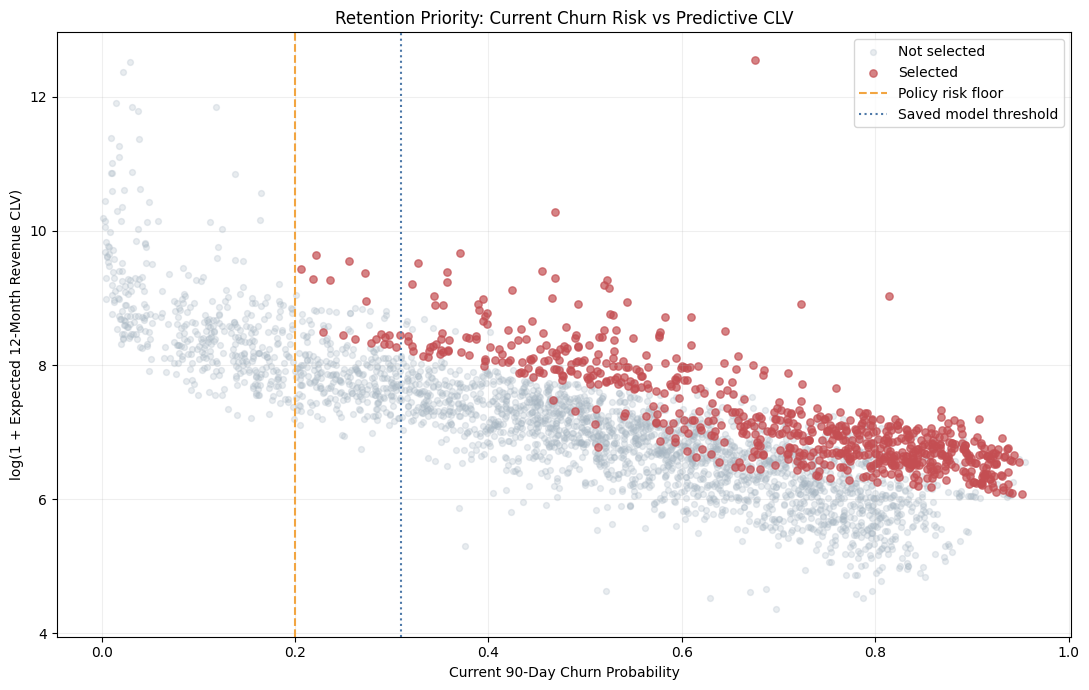

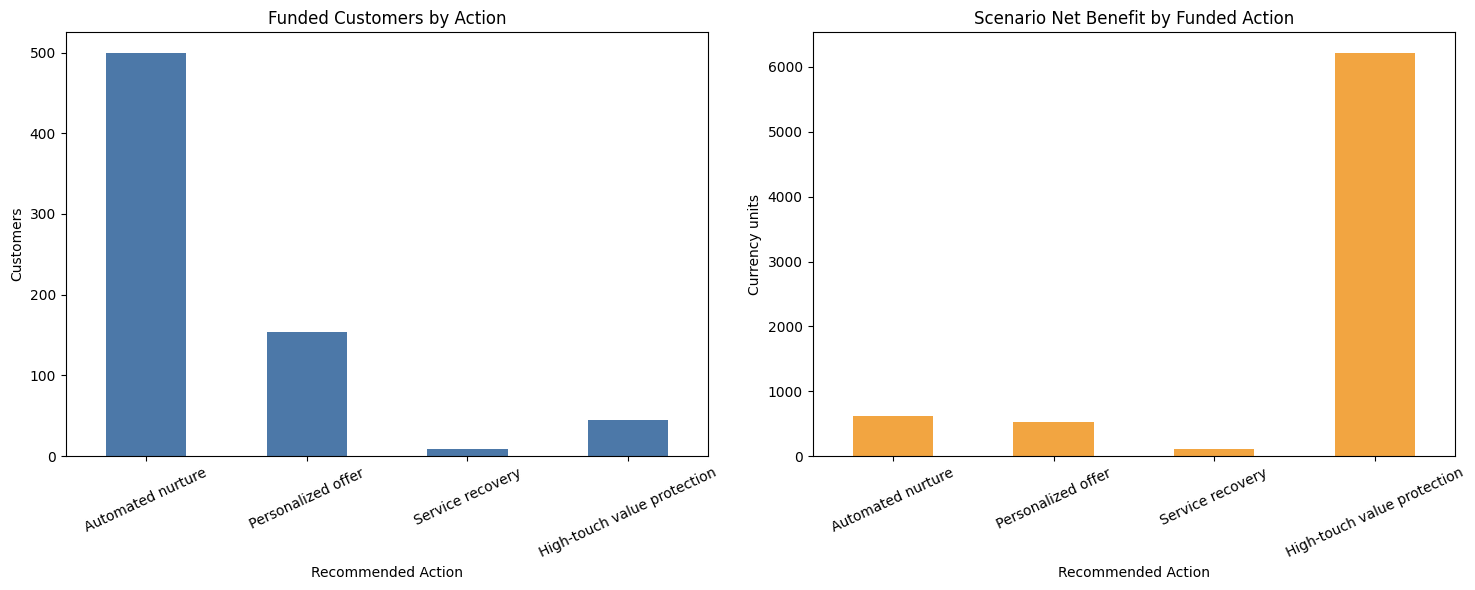

In [12]:
scored_plot = retention_decisions.loc[
    retention_decisions["churn_model_eligible"]
]
selected_plot = scored_plot.loc[scored_plot["campaign_selected"]]
unselected_plot = scored_plot.loc[~scored_plot["campaign_selected"]]

plt.figure(figsize=(11, 7))
plt.scatter(
    unselected_plot["churn_probability"],
    np.log1p(unselected_plot["expected_revenue_clv_12m"]),
    alpha=0.25,
    s=18,
    color="#A7B6C2",
    label="Not selected",
)
plt.scatter(
    selected_plot["churn_probability"],
    np.log1p(selected_plot["expected_revenue_clv_12m"]),
    alpha=0.70,
    s=28,
    color="#C44E52",
    label="Selected",
)
plt.axvline(
    DECISION_CONFIG["policy_risk_floor"],
    color="#F2A541",
    linestyle="--",
    label="Policy risk floor",
)
plt.axvline(
    MODEL_THRESHOLD,
    color="#4C78A8",
    linestyle=":",
    label="Saved model threshold",
)
plt.title("Retention Priority: Current Churn Risk vs Predictive CLV")
plt.xlabel("Current 90-Day Churn Probability")
plt.ylabel("log(1 + Expected 12-Month Revenue CLV)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "retention_risk_value_matrix.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

selected_action_summary = (
    campaign_targets
    .groupby("recommended_action", observed=True)
    .agg(
        selected_customers=("customer_id", "nunique"),
        scenario_net_benefit=("scenario_expected_net_benefit", "sum"),
    )
    .reindex(ACTION_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
selected_action_summary["selected_customers"].plot(
    kind="bar",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].set_title("Funded Customers by Action")
axes[0].set_xlabel("Recommended Action")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=25)

selected_action_summary["scenario_net_benefit"].plot(
    kind="bar",
    ax=axes[1],
    color="#F2A541",
)
axes[1].set_title("Scenario Net Benefit by Funded Action")
axes[1].set_xlabel("Recommended Action")
axes[1].set_ylabel("Currency units")
axes[1].tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "retention_action_economics.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

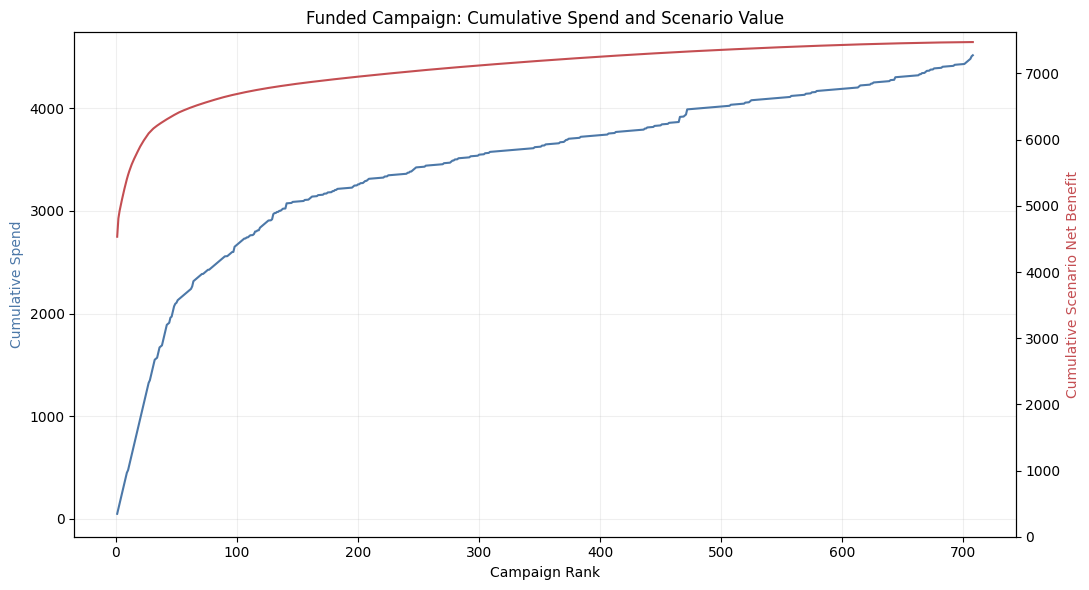

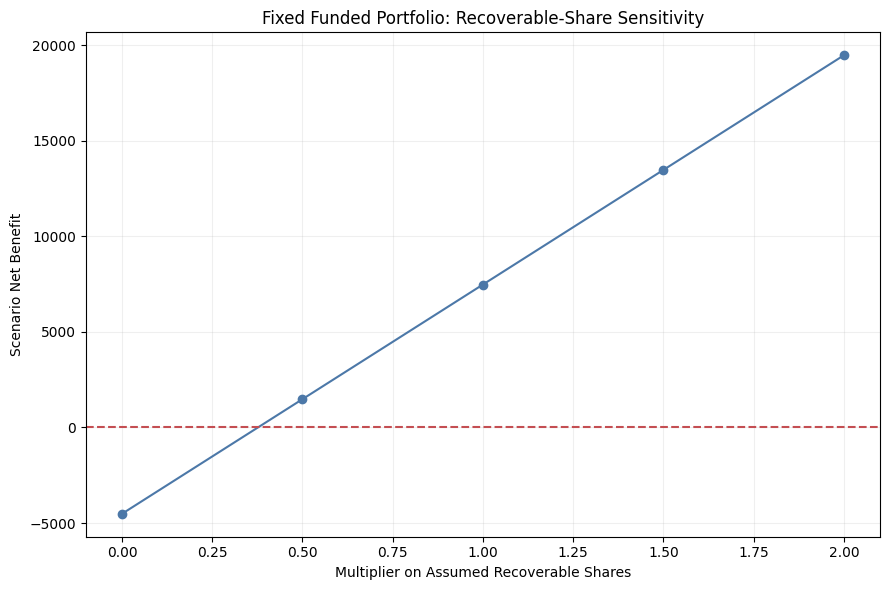

,recoverable_share_multiplier,scenario_retention_benefit,campaign_cost,scenario_net_benefit
0,0.000,0.000,"4,515.000","-4,515.000"
1,0.500,"5,994.744","4,515.000","1,479.744"
2,1.000,"11,989.488","4,515.000","7,474.488"
3,1.500,"17,984.232","4,515.000","13,469.232"
4,2.000,"23,978.976","4,515.000","19,463.976"


In [13]:
campaign_targets["cumulative_spend"] = campaign_targets[
    "intervention_cost"
].cumsum()
campaign_targets["cumulative_scenario_net_benefit"] = campaign_targets[
    "scenario_expected_net_benefit"
].cumsum()

fig, axis_left = plt.subplots(figsize=(11, 6))
axis_right = axis_left.twinx()
axis_left.plot(
    campaign_targets["campaign_rank"],
    campaign_targets["cumulative_spend"],
    color="#4C78A8",
    label="Cumulative spend",
)
axis_right.plot(
    campaign_targets["campaign_rank"],
    campaign_targets["cumulative_scenario_net_benefit"],
    color="#C44E52",
    label="Cumulative scenario net benefit",
)
axis_left.set_title("Funded Campaign: Cumulative Spend and Scenario Value")
axis_left.set_xlabel("Campaign Rank")
axis_left.set_ylabel("Cumulative Spend", color="#4C78A8")
axis_right.set_ylabel(
    "Cumulative Scenario Net Benefit",
    color="#C44E52",
)
axis_right.set_ylim(bottom=0)
axis_left.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "retention_campaign_cumulative_value.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

sensitivity_rows = []
selected_base_preserved_revenue = (
    campaign_targets["scenario_revenue_at_risk_proxy"]
    * campaign_targets["assumed_recoverable_share"]
)
selected_cost = campaign_targets["intervention_cost"].sum()

for recovery_multiplier in [0.0, 0.5, 1.0, 1.5, 2.0]:
    scenario_benefit = (
        selected_base_preserved_revenue.sum()
        * recovery_multiplier
        * DECISION_CONFIG["gross_margin_rate"]
    )
    sensitivity_rows.append(
        {
            "recoverable_share_multiplier": recovery_multiplier,
            "scenario_retention_benefit": scenario_benefit,
            "campaign_cost": selected_cost,
            "scenario_net_benefit": scenario_benefit - selected_cost,
        }
    )

retention_sensitivity = pd.DataFrame(sensitivity_rows)

plt.figure(figsize=(9, 6))
plt.plot(
    retention_sensitivity["recoverable_share_multiplier"],
    retention_sensitivity["scenario_net_benefit"],
    marker="o",
    color="#4C78A8",
)
plt.axhline(0, color="#C44E52", linestyle="--")
plt.title("Fixed Funded Portfolio: Recoverable-Share Sensitivity")
plt.xlabel("Multiplier on Assumed Recoverable Shares")
plt.ylabel("Scenario Net Benefit")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "retention_assumption_sensitivity.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

display(retention_sensitivity)

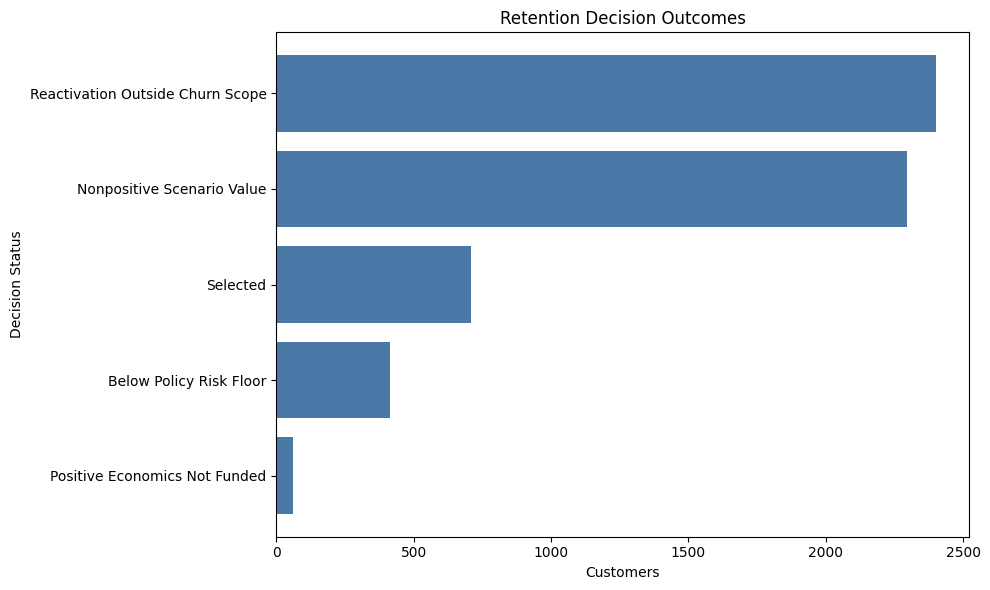

In [14]:
funnel_plot = retention_selection_funnel.sort_values("customers").copy()
funnel_plot["decision_status_label"] = (
    funnel_plot["decision_status"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

plt.figure(figsize=(10, 6))
plt.barh(
    funnel_plot["decision_status_label"],
    funnel_plot["customers"],
    color="#4C78A8",
)
plt.title("Retention Decision Outcomes")
plt.xlabel("Customers")
plt.ylabel("Decision Status")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "retention_selection_funnel.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

## Validation, outputs, and operational boundaries

The final checks reconcile model coverage, joins, scenario equations, optimization constraints, and saved outputs. The selected CSV is a **planning shortlist**, not a send-ready audience: customer consent, contactability, channel availability, suppression rules, offer eligibility, and prior-contact limits are not present in this dataset and must be applied before activation.

In [15]:
assert retention_decisions["customer_id"].is_unique
assert len(retention_decisions) == len(customer_clv) == 5_878
assert retention_decisions["churn_model_eligible"].sum() == len(
    current_churn_scores
)
assert not any(
    column.startswith("future_") or column == "churn_90d"
    for column in current_churn_scores.columns
)
assert current_churn_scores["churn_probability"].between(0, 1).all()
assert retention_decisions.loc[
    retention_decisions["churn_model_eligible"],
    "priority_score",
].between(0, 100).all()
assert not retention_decisions.loc[
    ~retention_decisions["churn_model_eligible"],
    "campaign_selected",
].any()
assert (campaign_targets["scenario_expected_net_benefit"] > 0).all()
assert (
    campaign_targets["churn_probability"]
    >= DECISION_CONFIG["policy_risk_floor"]
).all()
assert campaign_targets["intervention_cost"].sum() <= (
    DECISION_CONFIG["campaign_budget"] + 1e-8
)
assert len(campaign_targets) <= DECISION_CONFIG["campaign_capacity"]

for action, assumptions in ACTION_ASSUMPTIONS.items():
    assert (
        campaign_targets["recommended_action"].eq(action).sum()
        <= assumptions["capacity"]
    )

recomputed_net_benefit = (
    retention_decisions["churn_probability"]
    * retention_decisions["expected_revenue_clv_12m"]
    * retention_decisions["assumed_recoverable_share"]
    * DECISION_CONFIG["gross_margin_rate"]
    - retention_decisions["intervention_cost"]
)
np.testing.assert_allclose(
    retention_decisions.loc[
        retention_decisions["churn_model_eligible"],
        "scenario_expected_net_benefit",
    ],
    recomputed_net_benefit.loc[retention_decisions["churn_model_eligible"]],
    rtol=1e-12,
    atol=1e-12,
)

assert retention_selection_funnel["customers"].sum() == len(
    retention_decisions
)
assert retention_action_summary["selected_customers"].sum() == len(
    campaign_targets
)

print("Retention Decision Engine validation passed successfully.")

Retention Decision Engine validation passed successfully.


In [16]:
CURRENT_CHURN_SCORES_PATH.parent.mkdir(parents=True, exist_ok=True)

current_churn_scores.to_parquet(CURRENT_CHURN_SCORES_PATH, index=False)
retention_decisions = retention_decisions.sort_values(
    "customer_id"
).reset_index(drop=True)
retention_decisions.to_parquet(RETENTION_DECISIONS_PATH, index=False)

campaign_export_columns = [
    "campaign_rank",
    "customer_id",
    "decision_date",
    "churn_probability",
    "predicted_churn",
    "saved_model_threshold",
    "policy_risk_floor",
    "probability_alive",
    "historical_revenue",
    "expected_revenue_clv_12m",
    "rfm_value_tier",
    "clv_value_tier",
    "rfm_segment",
    "ml_cluster",
    "cluster_name",
    "recommended_action",
    "action_basis",
    "intervention_cost",
    "assumed_recoverable_share",
    "scenario_revenue_at_risk_proxy",
    "scenario_expected_retention_benefit",
    "scenario_expected_net_benefit",
    "scenario_benefit_cost_ratio",
    "breakeven_recoverable_share",
    "priority_score",
    "decision_status",
]
campaign_targets[campaign_export_columns].to_csv(
    REPORTS_DIR / "retention_campaign_targets.csv",
    index=False,
)
retention_action_summary.to_csv(
    REPORTS_DIR / "retention_action_summary.csv",
    index=False,
)
retention_segment_summary.to_csv(
    REPORTS_DIR / "retention_segment_summary.csv",
    index=False,
)
retention_value_tier_summary.to_csv(
    REPORTS_DIR / "retention_value_tier_summary.csv",
    index=False,
)
retention_selection_funnel.to_csv(
    REPORTS_DIR / "retention_selection_funnel.csv",
    index=False,
)
retention_sensitivity.to_csv(
    REPORTS_DIR / "retention_sensitivity.csv",
    index=False,
)
constraint_utilization.to_csv(
    REPORTS_DIR / "retention_constraint_utilization.csv",
    index=False,
)
campaign_concentration.to_csv(
    REPORTS_DIR / "retention_campaign_concentration.csv",
    index=False,
)

retention_assumptions = {
    "decision_date": str(DECISION_DATE),
    "decision_config": DECISION_CONFIG,
    "action_assumptions": ACTION_ASSUMPTIONS,
    "saved_churn_model_threshold": MODEL_THRESHOLD,
    "churn_prediction_horizon_days": PREDICTION_DAYS,
    "churn_model_eligibility_days": ELIGIBILITY_DAYS,
    "causal_disclaimer": (
        "Recoverable shares are scenario assumptions, not measured causal "
        "uplift. Validate with randomized experiments before activation."
    ),
    "activation_disclaimer": (
        "The campaign file is a planning shortlist. Apply consent, "
        "contactability, suppression, channel, and offer-eligibility rules."
    ),
}
(REPORTS_DIR / "retention_assumptions.json").write_text(
    json.dumps(retention_assumptions, indent=2),
    encoding="utf-8",
)

retention_engine_summary = {
    "decision_date": str(DECISION_DATE),
    "all_customers": int(len(retention_decisions)),
    "churn_model_eligible_customers": int(
        retention_decisions["churn_model_eligible"].sum()
    ),
    "outside_churn_model_scope_customers": int(
        (~retention_decisions["churn_model_eligible"]).sum()
    ),
    "candidate_customers": int(candidate_mask.sum()),
    "selected_customers": int(len(campaign_targets)),
    "campaign_budget": float(DECISION_CONFIG["campaign_budget"]),
    "campaign_spend": float(
        campaign_targets["intervention_cost"].sum()
    ),
    "campaign_capacity": int(DECISION_CONFIG["campaign_capacity"]),
    "scenario_expected_retention_benefit": float(
        campaign_targets["scenario_expected_retention_benefit"].sum()
    ),
    "scenario_expected_net_benefit": float(
        campaign_targets["scenario_expected_net_benefit"].sum()
    ),
    "top_target_scenario_net_benefit_share_pct": float(
        campaign_concentration.loc[
            campaign_concentration["top_targets"] == 1,
            "scenario_net_benefit_share_pct",
        ].iloc[0]
    ),
    "binding_constraints": constraint_utilization.loc[
        constraint_utilization["binding"],
        "constraint",
    ].tolist(),
    "mean_current_churn_probability": float(
        current_churn_scores["churn_probability"].mean()
    ),
    "median_current_churn_probability": float(
        current_churn_scores["churn_probability"].median()
    ),
    "decision_status_counts": {
        str(key): int(value)
        for key, value in retention_decisions["decision_status"]
        .value_counts()
        .items()
    },
    "selected_action_counts": {
        str(key): int(value)
        for key, value in campaign_targets["recommended_action"]
        .value_counts()
        .items()
    },
    "optimization_status": str(optimization_result.message),
    "feature_parity_test_date": str(PARITY_DATE),
    "feature_parity_rows": int(len(rebuilt_parity_snapshot)),
}
(REPORTS_DIR / "retention_engine_summary.json").write_text(
    json.dumps(retention_engine_summary, indent=2),
    encoding="utf-8",
)

print("=" * 72)
print("Retention Decision Engine completed successfully")
print("=" * 72)
print(f"All customers:          {len(retention_decisions):,}")
print(
    "Model-eligible:         "
    f"{retention_decisions['churn_model_eligible'].sum():,}"
)
print(f"Selected targets:       {len(campaign_targets):,}")
print(
    "Campaign spend:         "
    f"{campaign_targets['intervention_cost'].sum():,.2f}"
)
print(f"Saved decisions:        {RETENTION_DECISIONS_PATH}")

Retention Decision Engine completed successfully
All customers:          5,878
Model-eligible:         3,477
Selected targets:       708
Campaign spend:         4,515.00
Saved decisions:        C:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\retention_decisions.parquet


## Final business interpretation

The engine separates three decisions that are often conflated: who can be scored by the churn model, who has positive economics under the stated scenario, and who can be funded under real campaign constraints. This keeps long-lapsed customers visible without extrapolating a model beyond its 180-day training support, and it keeps budget-driven non-selection distinct from low customer value.

The funded ranking should be treated as a testable planning hypothesis. The default scenario's constraint table shows that Automated nurture capacity binds while the total budget and overall customer capacity do not; additional budget alone would therefore not expand this plan without changing channel capacity or the assumptions. Scenario net benefit is also concentrated in a few wholesale-like accounts, so top-ranked Strategic customers require manual account review before activation.

Before launch, apply operational eligibility rules and design a randomized holdout or equivalent experiment. Only that experiment can estimate incremental retention and replace the assumed recoverable shares with evidence.